##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



## 📚 Importation des Bibliothèques

In [ ]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
import kagglehub
import gc
import warnings
from tqdm import tqdm

### COLLECTE + NETTOYAGE + SOUS-ECHANTILLONNAGE

SAMPLE_SIZE = 150000
RANDOM_SEED = 42

LABEL_MAPPING = {
    'DrDoS_DNS': 'DNS', 'DrDoS_LDAP': 'LDAP', 'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NTP': 'NTP', 'DrDoS_NetBIOS': 'NetBIOS', 'DrDoS_SNMP': 'SNMP',
    'DrDoS_SSDP': 'SSDP', 'DrDoS_UDP': 'UDP', 'Syn': 'Syn',
    'TFTP': 'TFTP', 'UDPLag': 'UDPLag', 'UDP-lag': 'UDPLag',
    'Portmap': 'Portmap', 'BENIGN': 'BENIGN', 'Benign': 'BENIGN'
}

CLASSES_EXCLURE = ['WebDDoS','Portmap']

DROP_COLS = [
    "Unnamed: 0", "Flow ID", "Source IP", "Destination IP",
    "Source Port", "Destination Port", "Timestamp", "SimillarHTTP",
    "Fwd Header Length.1", "Inbound", "Flow ID.1", "Label.1"
]

# les fichiers a charger
FICHIERS = [
    'DrDoS_DNS.csv', 'DrDoS_LDAP.csv', 'DrDoS_MSSQL.csv',
    'DrDoS_NTP.csv', 'DrDoS_NetBIOS.csv', 'DrDoS_SNMP.csv',
    'DrDoS_SSDP.csv', 'DrDoS_UDP.csv', 'Syn.csv',
    'TFTP.csv', 'UDPLag.csv', 'LDAP.csv', 'MSSQL.csv',
    'NetBIOS.csv', 'Portmap.csv', 'UDP.csv', 'UDPLag.csv'
]

CLASSES = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
           'SNMP', 'SSDP', 'UDP', 'Syn', 'TFTP', 'UDPLag']

print("\nTelechargement du dataset...")
path = kagglehub.dataset_download("rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files")
print("Dataset: " + path)

# LOCALISATION DES FICHIERS
fichiers = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f in FICHIERS:
            fichiers.append({'nom': f, 'chemin': os.path.join(root, f)})

print(str(len(fichiers)) + " fichiers trouves")

# COLLECTE + NETTOYAGE + SOUS-ECHANTILLONNAGE
reservoir = {cls: [] for cls in CLASSES}
compteurs = {cls: 0 for cls in CLASSES}
total = sum([SAMPLE_SIZE for _ in CLASSES])

pbar = tqdm(total=total, desc="Collecte", unit="echantillons")

for info in fichiers:
    try:
        for chunk in pd.read_csv(info['chemin'], chunksize=100000, low_memory=False):
            chunk.columns = chunk.columns.str.strip()

            if 'Label' not in chunk.columns:
                continue

            #  Suppression colonnes
            chunk = chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns], errors='ignore')

            #  Mapping labels
            chunk['Label'] = chunk['Label'].astype(str).str.strip().replace(LABEL_MAPPING)
            chunk = chunk[~chunk['Label'].isin(CLASSES_EXCLURE)]

            #  Nettoyage
            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna().drop_duplicates()

            if chunk.empty:
                continue

            # Sous-echantillonnage
            for cls in CLASSES:
                if compteurs[cls] >= SAMPLE_SIZE:
                    continue

                sous = chunk[chunk['Label'] == cls]
                n = min(SAMPLE_SIZE - compteurs[cls], len(sous))

                if n > 0:
                    echantillon = sous.sample(n=n, random_state=RANDOM_SEED)
                    reservoir[cls].append(echantillon)
                    compteurs[cls] += n
                    pbar.update(n)

            del chunk
            gc.collect()

    except Exception as e:
        print("Erreur: " + str(e))
        continue

pbar.close()

frames = [pd.concat(v, ignore_index=True) for v in reservoir.values() if v]
df_final = pd.concat(frames, ignore_index=True)
df_final = df_final.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df_final.to_csv('cicddos2019_150k.csv', index=False)


# Chargement du dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df  = pd.read_csv("/content/drive/MyDrive/DDoS2019/cicddos2019.csv")

print(f" df : {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 df : (1583474, 78)


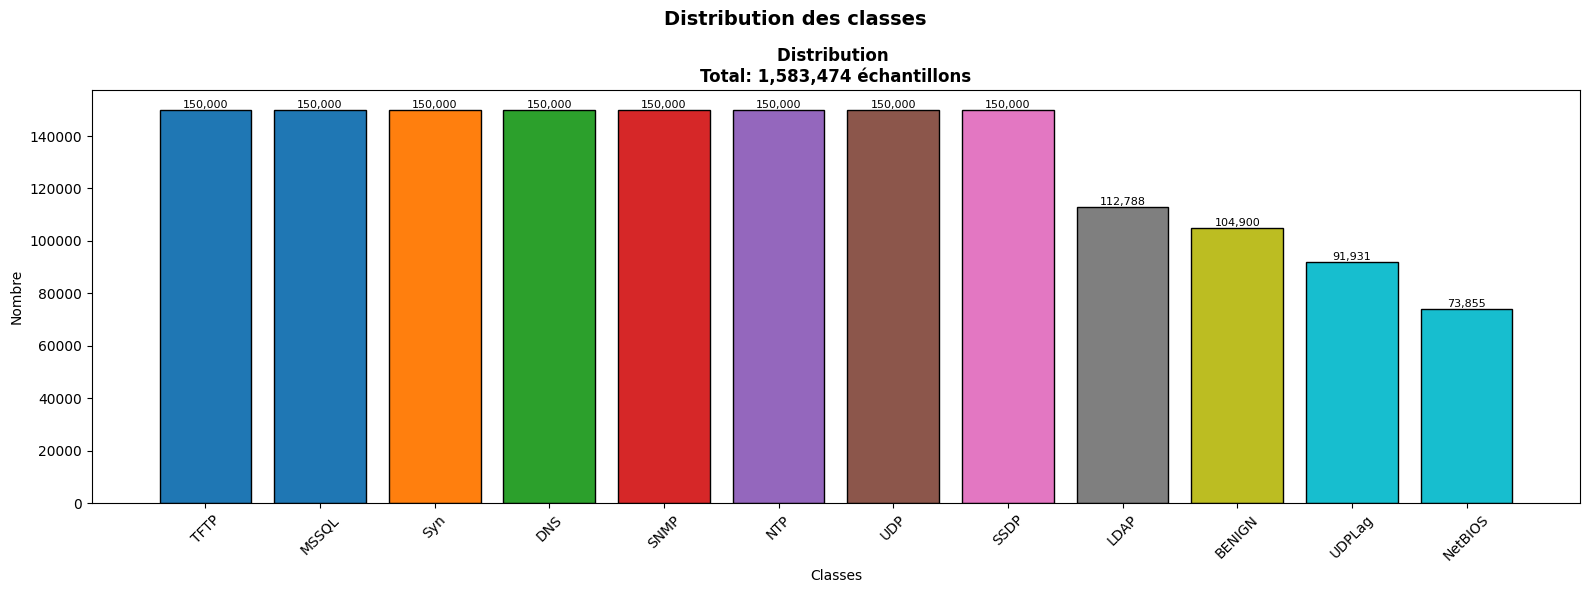

In [ ]:
# 2. Créer les graphiques
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# Train
train_counts = df['Label'].value_counts()
axes.bar(train_counts.index, train_counts.values,
         color=plt.cm.tab10(np.linspace(0, 1, len(train_counts))),
         edgecolor='black')
axes.set_title(f'Distribution \nTotal: {len(df):,} échantillons', fontsize=12, fontweight='bold')
axes.set_xlabel('Classes', fontsize=10)
axes.set_ylabel('Nombre', fontsize=10)
axes.tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(train_counts.items()):
    axes.text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# appercu du fichier train
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,9002080,8,0,4128.0,0.0,516.0,516.0,516.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,TFTP
1,17,48,2,0,1174.0,0.0,587.0,587.0,587.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,MSSQL
2,6,32226125,6,0,36.0,0.0,6.0,6.0,6.0,0.0,...,20,3.0,0.0,3.0,3.0,16113060.5,5.841253e+06,20243450.0,11982671.0,Syn
3,17,46,2,0,1274.0,0.0,637.0,637.0,637.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,DNS
4,17,2,2,0,2928.0,0.0,1464.0,1464.0,1464.0,0.0,...,317,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,SNMP


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583474 entries, 0 to 1583473
Data columns (total 78 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Protocol                  1583474 non-null  int64  
 1   Flow Duration             1583474 non-null  int64  
 2   Total Fwd Packets         1583474 non-null  int64  
 3   Total Backward Packets    1583474 non-null  int64  
 4   Fwd Packets Length Total  1583474 non-null  float64
 5   Bwd Packets Length Total  1583474 non-null  float64
 6   Fwd Packet Length Max     1583474 non-null  float64
 7   Fwd Packet Length Min     1583474 non-null  float64
 8   Fwd Packet Length Mean    1583474 non-null  float64
 9   Fwd Packet Length Std     1583474 non-null  float64
 10  Bwd Packet Length Max     1583474 non-null  float64
 11  Bwd Packet Length Min     1583474 non-null  float64
 12  Bwd Packet Length Mean    1583474 non-null  float64
 13  Bwd Packet Length Std     1

## Data Preprocessing

In [ ]:
# Vérifier la distribution de la variable cible dans les données d'entraînement
df["Label"].value_counts()

,count
Label,
TFTP,150000
MSSQL,150000
Syn,150000
DNS,150000
SNMP,150000
NTP,150000
UDP,150000
SSDP,150000
LDAP,112788


In [ ]:
# Afficher les colonnes avec une seule valeur unique
for i in df.columns:
    if df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


In [ ]:
# Trouver les colonnes avec une seule valeur unique
colonnes_valeur_unique = [col for col in df.columns if df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")
#Supprimer les colonnes à valeur unique
df = df.drop(columns=colonnes_valeur_unique)


Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
# Distribution de toutes les colonnes
for col in df.columns:
    print(col + ": " + str(df[col].nunique()) + " valeurs uniques")

Protocol: 3 valeurs uniques
Flow Duration: 389456 valeurs uniques
Total Fwd Packets: 607 valeurs uniques
Total Backward Packets: 454 valeurs uniques
Fwd Packets Length Total: 6259 valeurs uniques
Bwd Packets Length Total: 6279 valeurs uniques
Fwd Packet Length Max: 2587 valeurs uniques
Fwd Packet Length Min: 1468 valeurs uniques
Fwd Packet Length Mean: 11959 valeurs uniques
Fwd Packet Length Std: 12199 valeurs uniques
Bwd Packet Length Max: 1327 valeurs uniques
Bwd Packet Length Min: 241 valeurs uniques
Bwd Packet Length Mean: 9543 valeurs uniques
Bwd Packet Length Std: 9967 valeurs uniques
Flow Bytes/s: 467448 valeurs uniques
Flow Packets/s: 460529 valeurs uniques
Flow IAT Mean: 494754 valeurs uniques
Flow IAT Std: 721701 valeurs uniques
Flow IAT Max: 319827 valeurs uniques
Flow IAT Min: 4023 valeurs uniques
Fwd IAT Total: 376083 valeurs uniques
Fwd IAT Mean: 474285 valeurs uniques
Fwd IAT Std: 695587 valeurs uniques
Fwd IAT Max: 303124 valeurs uniques
Fwd IAT Min: 983 valeurs uniques

#### Identifier les colonnes catégorielles, les colonnes numériques

In [ ]:
SEUIL = 10

cat_cols = ([col for col in df.columns if df[col].dtypes == "O"] +
            [col for col in df.columns if df[col].nunique() < SEUIL and df[col].dtypes != "O"])

num_cols = [col for col in df.columns if df[col].dtypes != "O" and df[col].nunique() >= SEUIL]

print(f"Catégorielles : {len(cat_cols)}")
print(f"Numériques   : {len(num_cols)}")

Catégorielles : 8
Numériques   : 58


### Gestion des instances incoherentes

# valeurs infinie

In [ ]:
# analyse des valeurs infinies
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

### valeurs manquantes

In [ ]:
# Nombre total de valeurs manquantes
df.isnull().sum().sum()


np.int64(0)

### Lignes dupliquées

In [ ]:
print(f" Nombre de lignes dupliquées : {df.duplicated().sum()}")

 Nombre de lignes dupliquées : 427823


In [ ]:
# Supprimer les lignes dupliquées
df = df.drop_duplicates()

### Colonnes catégorielles


 Statistiques de Label :
Label
NTP        149507
TFTP       147124
UDP        139726
SSDP       138711
Syn        132919
BENIGN      95368
UDPLag      89305
MSSQL       73905
DNS         65249
SNMP        60182
LDAP        38144
NetBIOS     25511
Name: count, dtype: int64

Pourcentage :
Label
NTP        12.937037
TFTP       12.730833
UDP        12.090674
SSDP       12.002845
Syn        11.501656
BENIGN      8.252318
UDPLag      7.727679
MSSQL       6.395097
DNS         5.646082
SNMP        5.207628
LDAP        3.300650
NetBIOS     2.207500
Name: proportion, dtype: float64


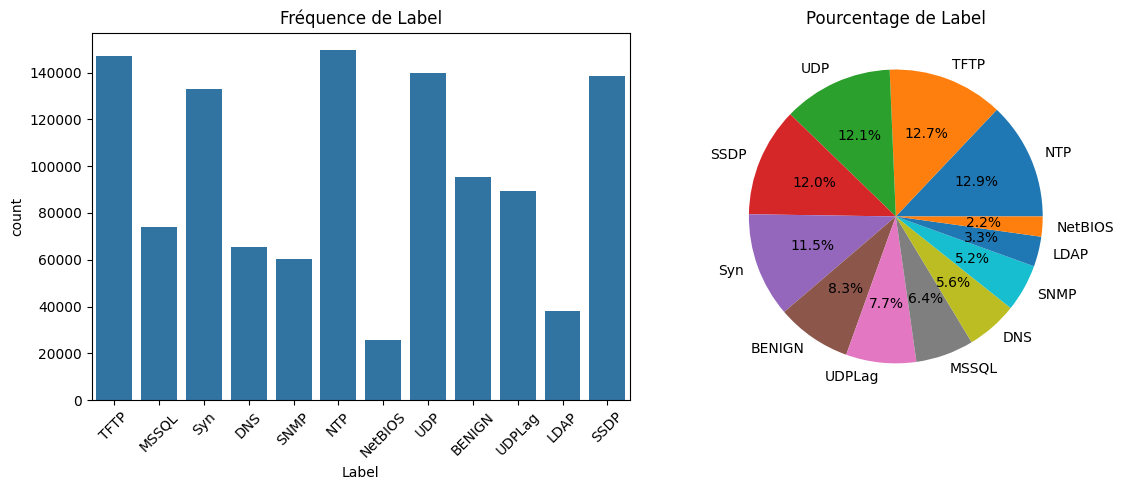

In [ ]:
def analyser_Label(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)

    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)

    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')

    plt.tight_layout()
    plt.show()

analyser_Label(df, 'Label')

In [ ]:
# Distribution des classes
df['Label'].value_counts()

,count
Label,
NTP,149507
TFTP,147124
UDP,139726
SSDP,138711
Syn,132919
BENIGN,95368
UDPLag,89305
MSSQL,73905
DNS,65249


In [ ]:
# convertion
for col in num_cols:
    df[col] = df[col].astype('float32')

for col in cat_cols:
    df[col] = df[col].astype('category')

### Suppresion de variable fortement colerer

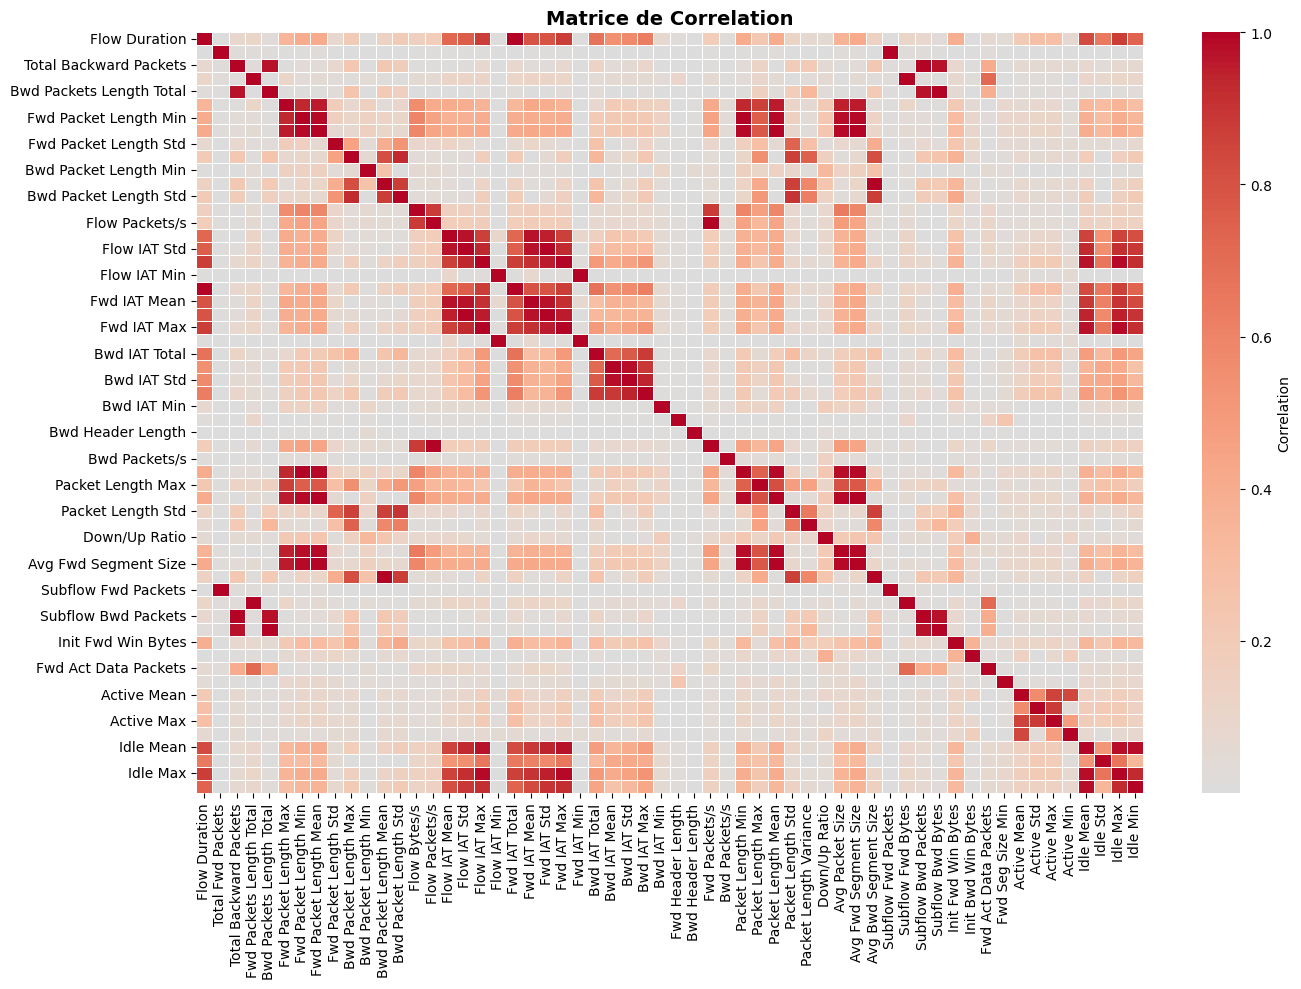

Colonnes fortement correlees (> 0.8): 32
['Bwd Packets Length Total', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Packets/s', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [ ]:
#Selectionner les colonnes numeriques
colonnes_numeriques = df.select_dtypes(include=[np.number])

#  Calculer la matrice de correlation_
matrice_correlation = colonnes_numeriques.corr().abs()

# Masque pour le triangle superieur
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

# 4. Afficher la heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matrice_correlation,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Matrice de Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifier les correlations elevees
triangle_superieur = matrice_correlation.where(masque)

colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns
    if any(triangle_superieur[col] > 0.8)
]

print("Colonnes fortement correlees (> 0.8): " + str(len(colonnes_fortement_correlees)))
print(colonnes_fortement_correlees)

In [ ]:
# suppression des colonnes fortement corrélées
df.drop(colonnes_fortement_correlees, axis=1, inplace=True)


In [ ]:
df.shape

(1155651, 34)

### Division en ensembles d'entraînement, validation et test


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("Label", axis=1), df["Label"], test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)

print(f"    X_train : {X_train.shape}")
print(f"    X_val   : {X_val.shape}")
print(f"    X_test  : {X_test.shape}")

    X_train : (808955, 33)
    X_val   : (115565, 33)
    X_test  : (231131, 33)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 808955 entries, 429199 to 910170
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  808955 non-null  category
 1   Flow Duration             808955 non-null  float32 
 2   Total Fwd Packets         808955 non-null  float32 
 3   Total Backward Packets    808955 non-null  float32 
 4   Fwd Packets Length Total  808955 non-null  float32 
 5   Fwd Packet Length Max     808955 non-null  float32 
 6   Fwd Packet Length Std     808955 non-null  float32 
 7   Bwd Packet Length Max     808955 non-null  float32 
 8   Bwd Packet Length Min     808955 non-null  float32 
 9   Flow Bytes/s              808955 non-null  float32 
 10  Flow IAT Mean             808955 non-null  float32 
 11  Flow IAT Min              808955 non-null  float32 
 12  Bwd IAT Total             808955 non-null  float32 
 13  Bwd IAT Mean              808

In [ ]:
print(pd.Series(y_train).value_counts())

Label
NTP        104638
TFTP       103081
UDP         97776
SSDP        97060
Syn         93251
BENIGN      66658
UDPLag      62444
MSSQL       51685
DNS         45713
SNMP        42131
LDAP        26720
NetBIOS     17798
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

#  Encoder la cible
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_val = le_target.transform(y_val)
y_test = le_target.transform(y_test)

print(f" Classes: {le_target.classes_}")
print(f" Mapping: {dict(enumerate(le_target.classes_))}")
#  Sauvegarder
joblib.dump(le_target, '/content/drive/MyDrive/DDoS2019/label_encoder_ddos.pkl')

 Classes: ['BENIGN' 'DNS' 'LDAP' 'MSSQL' 'NTP' 'NetBIOS' 'SNMP' 'SSDP' 'Syn' 'TFTP'
 'UDP' 'UDPLag']
 Mapping: {0: 'BENIGN', 1: 'DNS', 2: 'LDAP', 3: 'MSSQL', 4: 'NTP', 5: 'NetBIOS', 6: 'SNMP', 7: 'SSDP', 8: 'Syn', 9: 'TFTP', 10: 'UDP', 11: 'UDPLag'}


['/content/drive/MyDrive/DDoS2019/label_encoder_ddos.pkl']

In [ ]:
# Mise à l'échelle des caractéristiques
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
joblib.dump(scaler, '/content/drive/MyDrive/DDoS2019/scaler_ddos.pkl')

['/content/drive/MyDrive/DDoS2019/scaler_ddos.pkl']


🔹 Modèle : Random Forest
Temps d'entraînement : 264.60 s
 Accuracy : 0.8000

 Rapport de classification :
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19188
         DNS       0.72      0.63      0.67     13006
        LDAP       0.61      0.72      0.66      7607
       MSSQL       0.80      0.89      0.84     14836
         NTP       0.98      0.99      0.98     29921
     NetBIOS       0.75      0.63      0.68      5170
        SNMP       0.77      0.79      0.78     12032
        SSDP       0.50      0.49      0.50     27785
         Syn       1.00      1.00      1.00     26347
        TFTP       0.97      0.97      0.97     29317
         UDP       0.50      0.54      0.52     27982
      UDPLag       0.86      0.72      0.78     17940

    accuracy                           0.80    231131
   macro avg       0.79      0.78      0.78    231131
weighted avg       0.80      0.80      0.80    231131



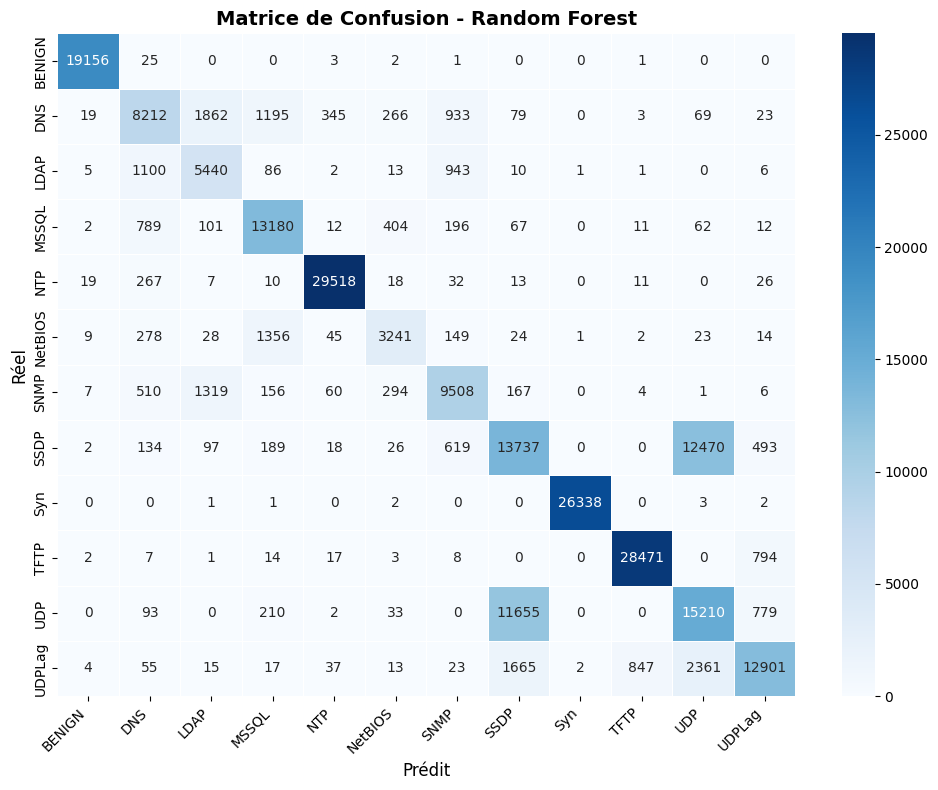

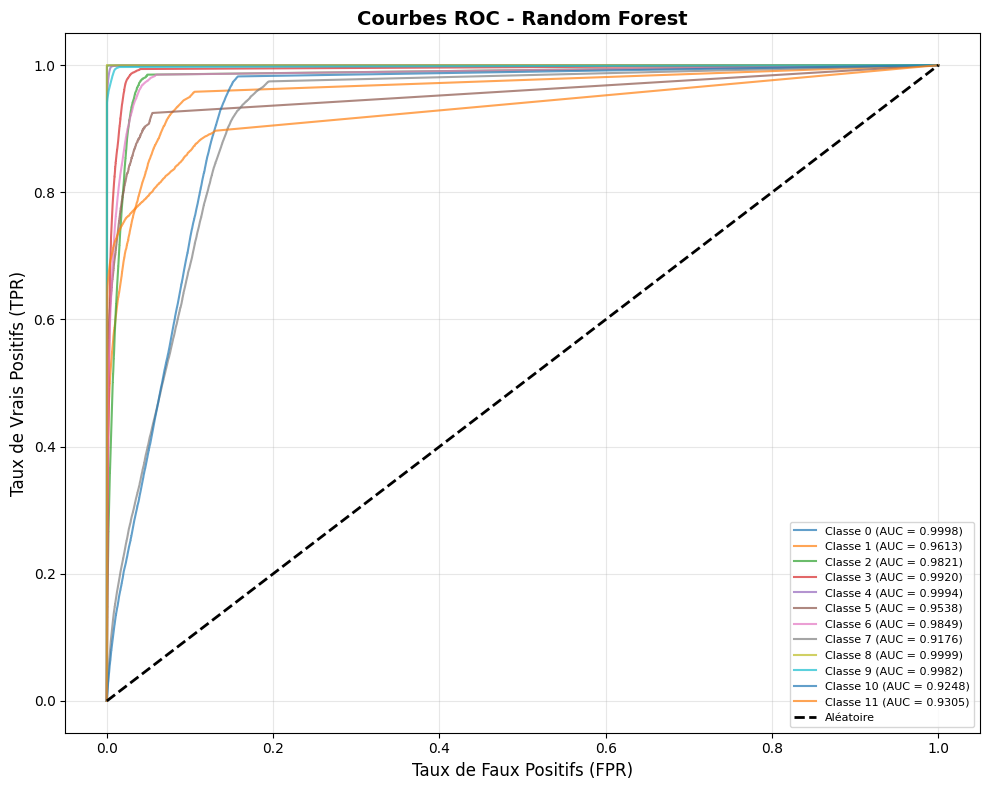


🔹 Modèle : XGBoost
Temps d'entraînement : 158.02 s
 Accuracy : 0.8198

 Rapport de classification :
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19188
         DNS       0.75      0.63      0.68     13006
        LDAP       0.64      0.67      0.65      7607
       MSSQL       0.79      0.93      0.86     14836
         NTP       0.98      0.99      0.99     29921
     NetBIOS       0.85      0.61      0.71      5170
        SNMP       0.73      0.84      0.78     12032
        SSDP       0.65      0.32      0.43     27785
         Syn       1.00      1.00      1.00     26347
        TFTP       0.98      0.97      0.98     29317
         UDP       0.52      0.84      0.64     27982
      UDPLag       0.94      0.72      0.82     17940

    accuracy                           0.82    231131
   macro avg       0.82      0.79      0.79    231131
weighted avg       0.83      0.82      0.81    231131



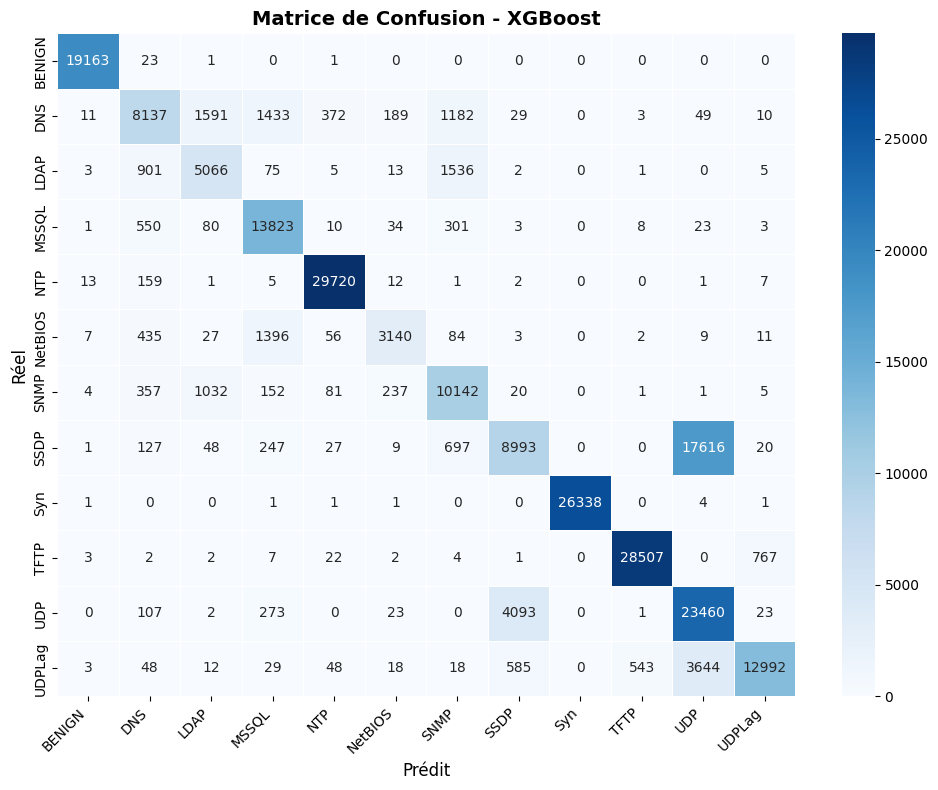

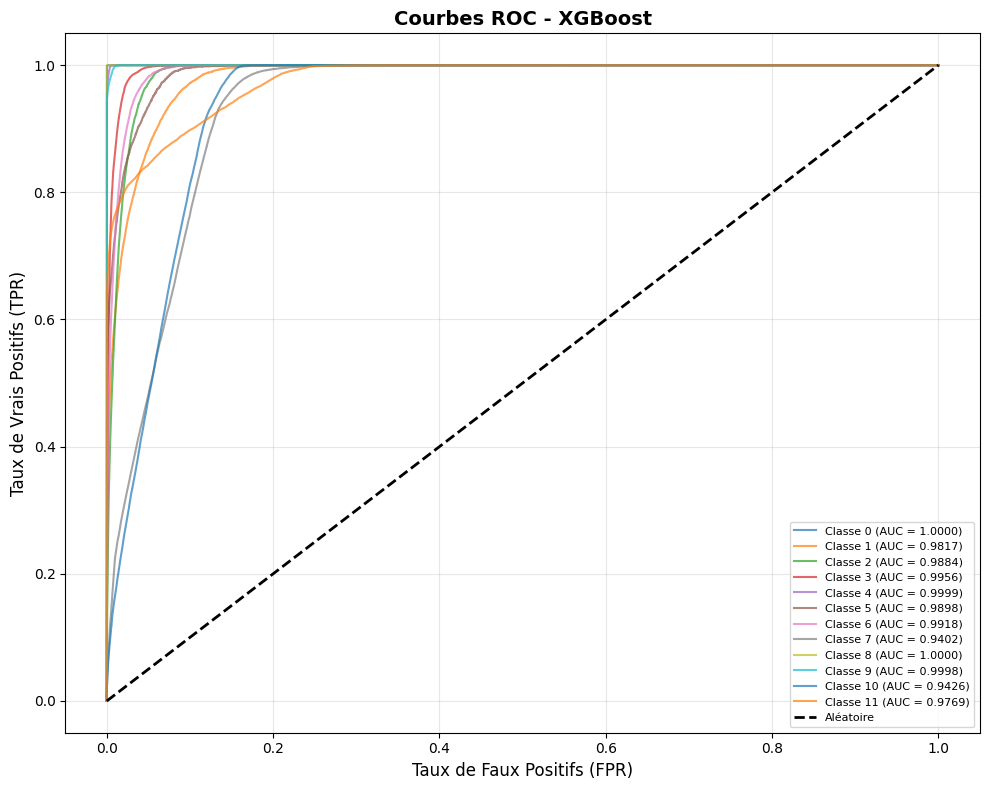


🔹 Modèle : Bagging (DecisionTree)
Temps d'entraînement : 101.22 s
 Accuracy : 0.8000

 Rapport de classification :
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19188
         DNS       0.71      0.65      0.68     13006
        LDAP       0.62      0.72      0.67      7607
       MSSQL       0.81      0.88      0.84     14836
         NTP       0.98      0.99      0.98     29921
     NetBIOS       0.75      0.63      0.69      5170
        SNMP       0.77      0.79      0.78     12032
        SSDP       0.50      0.50      0.50     27785
         Syn       1.00      1.00      1.00     26347
        TFTP       0.97      0.97      0.97     29317
         UDP       0.50      0.53      0.52     27982
      UDPLag       0.86      0.72      0.78     17940

    accuracy                           0.80    231131
   macro avg       0.79      0.78      0.78    231131
weighted avg       0.80      0.80      0.80    231131



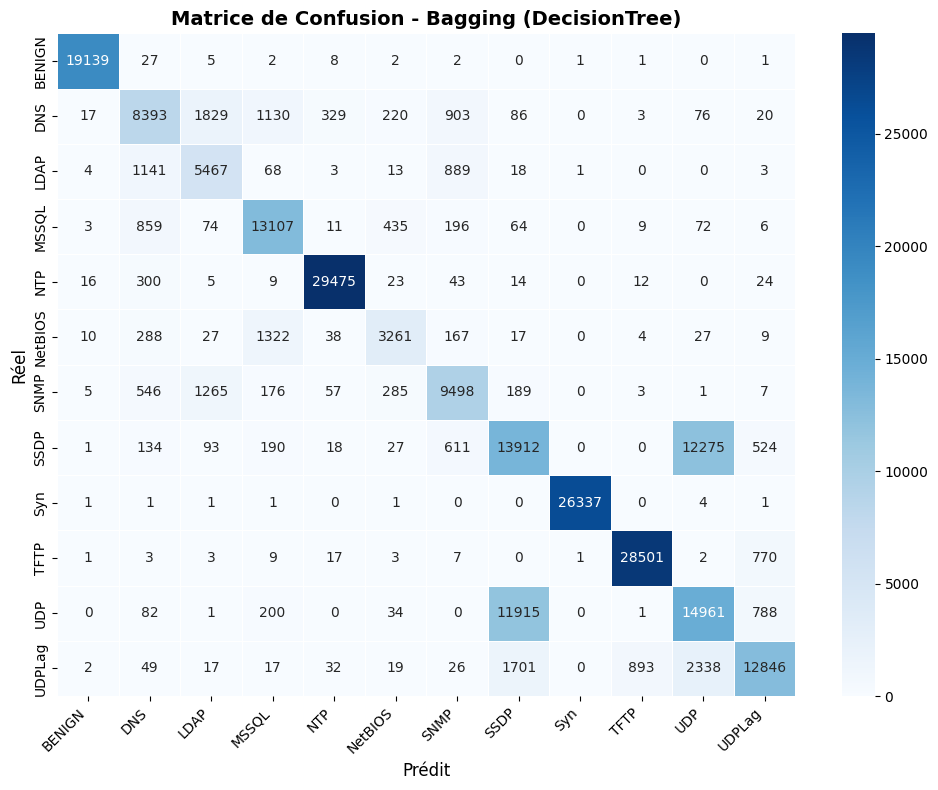

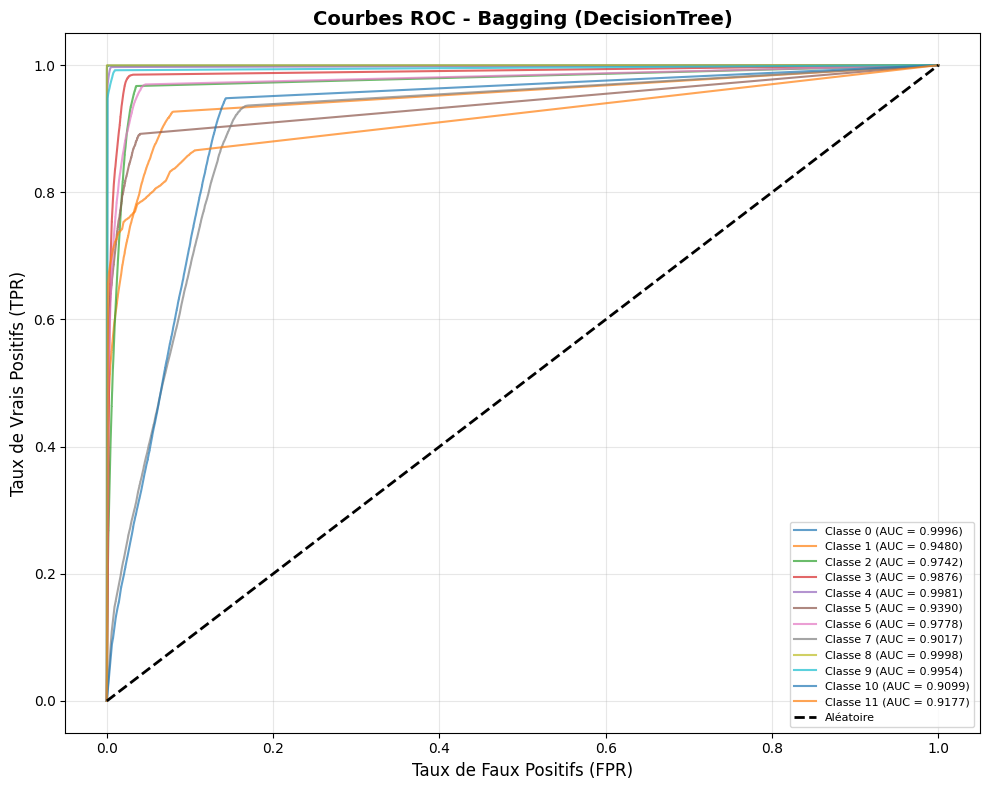

COMPARAISON DES MODÈLES (Accuracy)
Random Forest        : 0.8000
XGBoost              : 0.8198
Bagging (DecisionTree) : 0.8000


In [ ]:
import joblib
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

def train_models(X_train, y_train, X_test, y_test, class_names):


    # 1. Définition des modèles (paramètres par défaut)
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'Bagging (DecisionTree)': BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                    n_estimators=10, random_state=42)
    }

    results = {}

    # 2. Entraînement et évaluation pour chaque modèle
    for name, model in models.items():
        print(f"\n{'='*60}")
        print(f"🔹 Modèle : {name}")
        print('='*60)

        # Entraînement
        start = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        print(f"Temps d'entraînement : {elapsed:.2f} s")

        # Prédictions
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        # Métriques
        acc = accuracy_score(y_test, y_pred)
        print(f" Accuracy : {acc:.4f}")
        print("\n Rapport de classification :")
        print(classification_report(y_test, y_pred, target_names=class_names))

        # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5)
        plt.title(f'Matrice de Confusion - {name}', fontsize=14, fontweight='bold')
        plt.xlabel('Prédit', fontsize=12)
        plt.ylabel('Réel', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Courbes ROC (multiclasse)
        n_classes = len(np.unique(y_train))
        y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

        plt.figure(figsize=(10, 8))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            plt.plot(fpr, tpr, label=f'Classe {i} (AUC = {auc:.4f})', alpha=0.7)

        plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire", linewidth=2)
        plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
        plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
        plt.title(f'Courbes ROC - {name}', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right', fontsize=8)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Sauvegarde des résultats pour comparaison
        results[name] = {
            'accuracy': acc,
            'model': model,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

    # 3. Comparaison finale des accuracies
    print("COMPARAISON DES MODÈLES (Accuracy)")
    for name, res in results.items():
        print(f"{name:20} : {res['accuracy']:.4f}")

    return results
class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS', 'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']
results = train_models(X_train, y_train, X_test, y_test, class_names)


In [ ]:
import joblib
best = results[max(results, key=lambda k: results[k]['accuracy'])]
joblib.dump(best['model'], '/content/drive/MyDrive/DDoS2019/model.joblib')

['/content/drive/MyDrive/DDoS2019/model.joblib']

In [ ]:
nnnnnnnnnnn

NameError: name 'nnnnnnnnnnn' is not defined

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
plt.figure(figsize=(12, 6))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution des Classes - y_train')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_train, y_train = undersampler.fit_resample(X_train, y_train)

plt.figure(figsize=(12, 6))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution des Classes - y_train')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(" Entraînement de Random Forest...")

rf = RandomForestClassifier()

# Entraîner le modèle
start = time.time()
rf.fit(X_train, y_train)
temps = time.time() - start
print(f"    Temps d'entraînement : {temps/60:.2f} min")
# EVALUER
y_pred = rf.predict(X_test)

print(f"\n Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\n Rapport de classification:")
print(classification_report(y_test, y_pred))

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)
plt.title('Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### OPTIMISATION RandomizedSearchCV


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train, y_train)

print("Meilleurs paramètres :")
print(search.best_params_)

print("Meilleur F1 Macro :")
print(search.best_score_)

In [ ]:
import joblib
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(" Entraînement de Random Forest...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    criterion='gini',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Entraîner le modèle
start = time.time()
rf.fit(X_train, y_train)
temps = time.time() - start
print(f"    Temps d'entraînement : {temps/60:.2f} min")
# EVALUER
y_pred = rf.predict(X_test)

print(f"\n Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\n Rapport de classification:")
print(classification_report(y_test, y_pred))

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)
plt.title('Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [ ]:
mmmmmmmmmmmmmmmmmmmmn

In [ ]:
def train_model(X_train, X_test, y_train, y_test):
    modeles = {
        "Random Forest": RandomForestClassifier(),

    }
    # entrainement des modeles
    scores_list = []
    modeles_entraines = {}
    predictions = {}
    probabilites = {}

    # Figure ROC
    plt.figure(figsize=(12, 8))

    for nom, modele in tqdm(modeles.items(), desc="Entraînement"):
        print(f"\n Entraînement de {nom}...")
        modele.fit(X_train, y_train)
        modeles_entraines[nom] = modele
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)
        predictions[nom] = y_pred
        probabilites[nom] = y_proba

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

        # Validation croisée
        cv = np.mean(cross_val_score(modele, X_train, y_train, cv=3, scoring='f1_weighted', n_jobs=-1))

        # Courbes ROC
        for i in range(nb_classes):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f'{nom} - Classe {i}', alpha=0.7)

        scores_list.append({
            "Modèle": nom,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),
            "CV Score": round(cv, 4)
        })

        print(f"   Accuracy : {accuracy:.4f} | F1 : {f1:.4f} | CV : {cv:.4f}")


        modeles_entraines[nom] = modele
        # Prédictions
        y_proba = modele.predict(X_test, verbose=0)
        y_pred = np.argmax(y_proba, axis=1)
        predictions[nom] = y_pred
        probabilites[nom] = y_proba

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        nb_classes = len(np.unique(y_train))
        # Courbes ROC
        for i in range(nb_classes):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f'{nom} - Classe {i}', alpha=0.7, linestyle='--')

        scores_list.append({
            "Modèle": nom,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),
            "CV Score": 0
        })

        print(f" Accuracy : {accuracy:.4f} | F1 : {f1:.4f}")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Aléatoire")
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    scores = pd.DataFrame(scores_list)
    return scores, modeles_entraines, predictions, probabilites

scores, modeles, predictions, probabilites = train_model(X_train, X_val, y_train, y_val)

print("COMPARAISON DES MODÈLES")
display(scores.style.background_gradient(cmap='viridis'))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

fig, axes = plt.subplots(1, len(modeles), figsize=(5*len(modeles), 5))
if len(modeles) == 1:
    axes = [axes]

# Stocker les résultats
resultats = {}

for ax, (nom, _) in zip(axes, modeles.items()):
    # Matrice de confusion
    cm = confusion_matrix(y_val, predictions[nom])

    # Métriques
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, cm.sum())

    # Affichage
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlOrBr',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(nom, fontsize=14, fontweight='bold')
    ax.set_xlabel("Prédit", fontsize=12)
    ax.set_ylabel("Réel", fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle("Matrices de confusion des modèles", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

for nom, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f" {nom}")
    print('='*60)
    print(classification_report(y_val, y_pred, target_names=class_names, digits=4))


In [ ]:
meilleur_idx = scores['Accuracy'].idxmax()
meilleur_nom = scores.loc[meilleur_idx, 'Modèle']
meilleur_modele = modeles[meilleur_nom]

print(f"\n Meilleur modèle : {meilleur_nom}")
print(f"   Accuracy sur validation : {scores.loc[meilleur_idx, 'Accuracy']:.4f}")

y_pred = meilleur_modele.predict(X_test)
y_proba = meilleur_modele.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n Performances sur l'ensemble de test :")
print(f"  {'Accuracy  :':<15} {acc:.4f} ({acc*100:.2f}%)")
print(f"  {'Precision :':<15} {prec:.4f} ({prec*100:.2f}%)")
print(f"  {'Recall    :':<15} {rec:.4f} ({rec*100:.2f}%)")
print(f"  {'F1-Score  :':<15} {f1:.4f} ({f1*100:.2f}%)")

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 10})
plt.title(f'Matrice de Confusion - {meilleur_nom}', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=14)
plt.ylabel('Réel', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f'matrice_confusion_{meilleur_nom}.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


In [ ]:
# Prendre la 10ème ligne (index 9)
X_sample = X_test[9:10]  # Index 9 = 10ème ligne
y_sample = y_test[9:10]

# Prédire
y_pred_sample = meilleur_modele.predict(X_sample)

# Afficher le résultat
print(f"Réel : {y_sample[0]}")
print(f"Prédit : {y_pred_sample[0]}")
print(f"Correct : {y_sample[0] == y_pred_sample[0]}")

In [ ]:
# Récupérer les noms des colonnes
feature_names = train_df.drop('Label', axis=1).columns

X_sample = X_test[9:10]
y_sample = y_test[9:10]
y_pred_sample = meilleur_modele.predict(X_sample)

print("\n📊 10ème ligne - Variables :")
for name, value in zip(feature_names, X_sample[0]):
    print(f"  {name}: {value:.8f}" if isinstance(value, float) else f"  {name}: {value}")

class_names = ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS',
               'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag']
print(f"\n🎯 Réel: {class_names[y_sample[0]]} | Prédit: {class_names[y_pred_sample[0]]}")

In [ ]:
nnnnn

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



# Nombre de caractéristiques
n_features = X_train.shape[1]
print(f"\n  📊 Nombre de caractéristiques : {n_features}")

# Normalisation (Min-Max Scaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Encodage des labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Nombre de classes
n_classes = len(label_encoder.classes_)
print(f"  Nombre de classes : {n_classes}")
print(f"  Classes : {label_encoder.classes_}")

# One-hot encoding
y_train_categorical = tf.keras.utils.to_categorical(y_train_encoded, num_classes=n_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val_encoded, num_classes=n_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test_encoded, num_classes=n_classes)



def build_cybernet_model(n_features, n_classes, binary=False):


    # Couche d'entrée
    inputs = layers.Input(shape=(n_features,))

    # Reshape pour LSTM et Conv1D
    x = layers.Reshape((n_features, 1))(inputs)

    # Bloc 1: LSTM + Conv1D
    lstm1 = layers.LSTM(n_features, return_sequences=True)(x)
    lstm1 = layers.LeakyReLU(alpha=0.01)(lstm1)

    conv1 = layers.Conv1D(filters=64, kernel_size=3, padding='same')(x)
    conv1 = layers.LeakyReLU(alpha=0.01)(conv1)
    conv1_adjusted = layers.Conv1D(filters=n_features, kernel_size=1, padding='same')(conv1)

    add1 = layers.Add()([lstm1, conv1_adjusted])
    pool1 = layers.MaxPooling1D(pool_size=2)(add1)

    # Bloc 2: LSTM + Conv1D
    lstm2 = layers.LSTM(39, return_sequences=True)(pool1)
    lstm2 = layers.LeakyReLU(alpha=0.01)(lstm2)

    conv2 = layers.Conv1D(filters=128, kernel_size=3, padding='same')(pool1)
    conv2 = layers.LeakyReLU(alpha=0.01)(conv2)
    conv2_adjusted = layers.Conv1D(filters=39, kernel_size=1, padding='same')(conv2)

    add2 = layers.Add()([lstm2, conv2_adjusted])
    pool2 = layers.MaxPooling1D(pool_size=2)(add2)

    # Flatten
    flatten1 = layers.Flatten()(pool2)

    # Bloc 3: Dense + Dense
    dense1 = layers.Dense(256)(flatten1)
    dense1 = layers.LeakyReLU(alpha=0.01)(dense1)
    dense1_reshaped = layers.Reshape((256, 1))(dense1)

    dense2 = layers.Dense(128)(flatten1)
    dense2 = layers.LeakyReLU(alpha=0.01)(dense2)
    dense2_padded = layers.ZeroPadding1D(padding=((0, 128)))(layers.Reshape((128, 1))(dense2))

    add3 = layers.Add()([dense1_reshaped, dense2_padded])
    pool3 = layers.MaxPooling1D(pool_size=2)(add3)

    # Bloc 4: Dense + Dense
    flatten2 = layers.Flatten()(pool3)

    dense3 = layers.Dense(512)(flatten2)
    dense3 = layers.LeakyReLU(alpha=0.01)(dense3)
    dense3_reshaped = layers.Reshape((512, 1))(dense3)

    dense4 = layers.Dense(256)(flatten2)
    dense4 = layers.LeakyReLU(alpha=0.01)(dense4)
    dense4_padded = layers.ZeroPadding1D(padding=((0, 256)))(layers.Reshape((256, 1))(dense4))

    add4 = layers.Add()([dense3_reshaped, dense4_padded])
    pool4 = layers.MaxPooling1D(pool_size=2)(add4)

    # Dropout
    dropout = layers.Dropout(0.2)(pool4)

    # Flatten final
    flatten_final = layers.Flatten()(dropout)

    # Couche de sortie
    if binary:
        outputs = layers.Dense(1, activation='sigmoid')(flatten_final)
    else:
        outputs = layers.Dense(n_classes, activation='softmax')(flatten_final)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ============================================================
# 3. MODÈLE MULTICLASSE
# ============================================================
print("\n" + "="*70)
print(" 3. MODÈLE MULTICLASSE (12 classes)")
print("="*70)

model = build_cybernet_model(n_features, n_classes, binary=False)
model.summary()

# Paramètres
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n  ✅ Modèle multiclasse compilé")
print(f"    Optimizer : Adam (lr={LEARNING_RATE})")
print(f"    Loss : Categorical Crossentropy")
print(f"    Batch size : {BATCH_SIZE}")
print(f"    Epochs : {EPOCHS}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cybernet_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]



history = model.fit(
    X_train_scaled, y_train_categorical,
    validation_data=(X_val_scaled, y_val_categorical),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


print("\n" + "="*70)
print(" 5. ÉVALUATION MULTICLASSE")
print("="*70)

y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n   Performances multiclasse :")
print(f"    Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"    Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"    Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"    F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

print("\n   Classification Report :")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

# Matrice de confusion multiclasse
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Modèle Cybernet Multiclasse', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérités', fontsize=12)
plt.tight_layout()
plt.show()

# Courbes d'apprentissage multiclasse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r-s', label='Val Accuracy', linewidth=2)
ax1.set_title('Accuracy - Modèle Cybernet Multiclasse', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
ax2.set_title('Loss - Modèle Cybernet Multiclasse', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



# Labels binaires
y_train_binary = np.where(y_train_encoded == 0, 0, 1)
y_val_binary = np.where(y_val_encoded == 0, 0, 1)
y_test_binary = np.where(y_test_encoded == 0, 0, 1)

print(f"\n    Distribution binaire :")
print(f"    Train - BENIGN: {sum(y_train_binary == 0):,}, ATTACK: {sum(y_train_binary == 1):,}")
print(f"    Val   - BENIGN: {sum(y_val_binary == 0):,}, ATTACK: {sum(y_val_binary == 1):,}")
print(f"    Test  - BENIGN: {sum(y_test_binary == 0):,}, ATTACK: {sum(y_test_binary == 1):,}")


model_binary = build_cybernet_model(n_features, n_classes, binary=True)

model_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n   Modèle binaire compilé")
print(f"    Optimizer : Adam (lr={LEARNING_RATE})")
print(f"    Loss : Binary Crossentropy")
print(f"    Batch size : {BATCH_SIZE}")

history_binary = model_binary.fit(
    X_train_scaled, y_train_binary,
    validation_data=(X_val_scaled, y_val_binary),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

y_pred_binary = (model_binary.predict(X_test_scaled) > 0.5).astype(int)

accuracy_bin = accuracy_score(y_test_binary, y_pred_binary)
precision_bin = precision_score(y_test_binary, y_pred_binary)
recall_bin = recall_score(y_test_binary, y_pred_binary)
f1_bin = f1_score(y_test_binary, y_pred_binary)

print(f"\n   Performances binaires :")
print(f"    Accuracy  : {accuracy_bin:.4f} ({accuracy_bin*100:.2f}%)")
print(f"    Precision : {precision_bin:.4f} ({precision_bin*100:.2f}%)")
print(f"    Recall    : {recall_bin:.4f} ({recall_bin*100:.2f}%)")
print(f"    F1-Score  : {f1_bin:.4f} ({f1_bin*100:.2f}%)")

print("\n  Classification Report (Binaire) :")
print(classification_report(y_test_binary, y_pred_binary, target_names=['BENIGN', 'ATTACK'], digits=4))

# Matrice de confusion binaire
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
tn, fp, fn, tp = cm_binary.ravel()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            annot_kws={'size': 16})
plt.title('Matrice de Confusion - Modèle Cybernet Binaire', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=14)
plt.ylabel('Vérités', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=300)
plt.show()

print(" COURBES D'APPRENTISSAGE BINAIRES")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history_binary.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(history_binary.history['val_accuracy'], 'r-s', label='Val Accuracy', linewidth=2)
ax1.set_title('Accuracy - Modèle Cybernet Binaire', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.98, 1.0)

# Loss
ax2.plot(history_binary.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(history_binary.history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
ax2.set_title('Loss - Modèle Cybernet Binaire', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sauvegarder les modèles
model.save('cybernet_multiclass_model.h5')
model_binary.save('cybernet_binary_model.h5')

# Sauvegarder le scaler et le label encoder
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("\n    Modèles et préprocesseurs sauvegardés :")
print("    - cybernet_multiclass_model.h5")
print("    - cybernet_binary_model.h5")
print("    - scaler.pkl")
print("    - label_encoder.pkl")



print(f"""
      Entraînement du modèle Cybernet terminé !

      Performances du modèle multiclasse (12 classes) :
    - Accuracy  : {accuracy*100:.2f}%
    - Precision : {precision*100:.2f}%
    - Recall    : {recall*100:.2f}%
    - F1-Score  : {f1*100:.2f}%

      Performances du modèle binaire (2 classes) :
    - Accuracy  : {accuracy_bin*100:.2f}%
    - Precision : {precision_bin*100:.2f}%
    - Recall    : {recall_bin*100:.2f}%
    - F1-Score  : {f1_bin*100:.2f}%

     Fichiers sauvegardés :
    - cybernet_multiclass_model.h5
    - cybernet_binary_model.h5
    - scaler.pkl
    - label_encoder.pkl
    - confusion_matrix_multi.png
    - confusion_matrix_binary.png
    - learning_curves_multi.png
    - learning_curves_binary.png


""")


# Exporter le meilleur modèle pour le déploiement

In [ ]:

# 7. Sauvegarder
import joblib
#joblib.dump(meilleur_modele, 'meilleur_modele.pkl')
#print(f"\n Modèle sauvegardé : meilleur_modele.pkl")

In [ ]:
#model.save('modele_cnn_ddos.h5')
#print(" Modèle CNN sauvegardé !")

In [ ]:
# 1. Récupérer les noms des colonnes
feature_names = train_df.drop('Label', axis=1).columns.tolist()

# 2. Convertir en DataFrames si nécessaire
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)
    #X_val = pd.DataFrame(X_val, columns=feature_names)
    X_test = pd.DataFrame(X_test, columns=feature_names)

# SELECTKBEST
selector = SelectKBest(f_classif, k=20)
selector.fit(X_train, y_train)
scores = selector.scores_
selected_indices = selector.get_support(indices=True)

df_kbest = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values('Score', ascending=False)

#  RANDOM FOREST
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SelectKBest
top20_kbest_df = df_kbest.head(20)
axes[0].barh(top20_kbest_df['Feature'][::-1], top20_kbest_df['Score'][::-1], color='steelblue')
axes[0].set_title("SelectKBest - Top 20", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Score F")

# Random Forest
top20_rf_df = importance_df.head(20)
axes[1].barh(top20_rf_df['Feature'][::-1], top20_rf_df['Importance'][::-1], color='darkorange')
axes[1].set_title("Random Forest - Top 20", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()
seuil = 0.05
meilleures_features_rf = importance_df[importance_df["Importance"] >= seuil]["Feature"].tolist()
#X_train = X_train[meilleures_features_rf]
#X_val = X_val[meilleures_features_rf]
#X_test = X_test[meilleures_features_rf]